In [ ]:
import marimo as mo

# Calcolo e plotting
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, LabelEncoder

# from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Dataset "sonar" e applicazione della LDA ad uno spazio di 60 feature

Le 60 feature corrispondono alle misure dei sensori su 60 bande di frequenza. Il dataset è stato importato dal link fornito, appendendo (puramente come scelta di stile) una riga di titoli. Le classi (etichette) sono rappresentate dalle lettere R (Roccia) e M (Mina) in base all'oggetto rilevato dalle misure del sonar.

Alla colonna delle etichette è stato applicato il `LabelEncoder` di `scikit-learn`, così da convertire le etichette, originariamente di tipo stringa, in valori numerici.

La *linear discriminant analysis* è qui applicata come classificatore, scalando prima i dati numerici con lo standard scaling.

In [ ]:
# Riga dei titoli
titles = [f"Banda {number}" for number in range(0, 60)]
titles.append("Oggetto")


df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data",
    names=titles,
)

# df["Oggetto"] = df["Oggetto"].replace({"R": 0, "M": 1}).infer_objects()

# Quello sopra è un approccio manuale, tuttavia sklearn ha già una funzione che fa esattamente la cosa sopra:

le = LabelEncoder()
df["Oggetto"] = le.fit_transform(df["Oggetto"])

# Scelta convenzionale in ML è di chiamare x il vettore dei dati
# ed y quello delle etichette

x = df.iloc[:, :-1]
y = df["Oggetto"].values.ravel()

df.head()
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Scaling delle feature e applicazione della LDA

In [ ]:
seed = random.randint(0, 50)
# per testare la performance del modello a partire da vari stati iniziali
fix_seed = 42
# per testare il funzionamento del codice

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, stratify=y
)

lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# Esecuzione del modello

In [ ]:
y_pred = lda.fit(x_train_scaled, y_train).predict(x_test_scaled)
# il dataset di test è come un foglio di verifica

## Metriche di performance

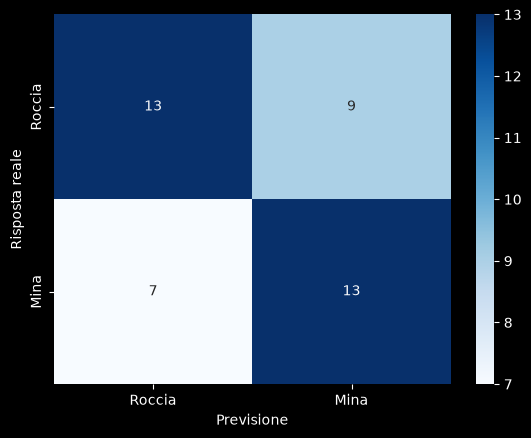

In [ ]:
from sklearn.metrics import confusion_matrix

confmat = confusion_matrix(y_test, y_pred)
labels = ["Roccia", "Mina"]

sns.heatmap(
    data=confmat,
    annot=True,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Previsione")
plt.ylabel("Risposta reale")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Calcolo delle figure di merito
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Stampa delle figure di merito

In [ ]:
mo.md(rf"""
Il modello appena eseguito ha restituito le seguenti metriche: 
- Accuratezza: ${round(accuracy, 4) * 100}\%$
- Precisione: ${round(precision, 4) * 100}\%$
- Recall: ${round(recall, 4) * 100}\%$
- F1-score: ${round(f1, 4) * 100}\%$
""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Il modello appena eseguito ha restituito le seguenti metriche: </span>
<ul>
<li>Accuratezza: $61.9\%$</li>
<li>Precisione: $62.19\%$</li>
<li>Recall: $61.9\%$</li>
<li>F1-score: $61.9\%$</li>
</ul></span>

I valori qui sopra si aggirano sulla fascia $70-80\%$ (con occasionali eccezioni), che può essere migliorata. Si applica allora un algoritmo di riduzione delle feature (esistono alcuni metodi già inclusi in scikit-learn, ma qui si opera un semplice for-loop).

# Feature selection sequenziale

Nell'allenamento di un algoritmo, possiamo **ridurre lo spazio delle feature**. Questo serve a:
- alleggerire computazionalmente l'algoritmo, poiché riducendo le dimensioni riduciamo le operazioni di analisi e calcolo
- *potenzialmente* migliorare la performance del modello: talvolta ridurre lo spazio delle feature rimuove qualsiasi statistica che per il modello è inutile o addirittura negativamente influente sull'apprendimento.

In [ ]:
feature_count = x.shape[1]
# visto che sappiamo che x è un vettore 1D in realtà va bene anche il metodo nativo .len(), anche perché ci aspettiamo uno scalare

print(feature_count)